In [2]:
import os 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

RAW = os.path.expanduser("~/Documents/2026MLpredictor/data/raw")
PROCESSED = os.path.expanduser("~/Documents/2026MLpredictor/data/processed") 

In [3]:
raw = pd.read_csv(os.path.join(RAW, "mit_house_results.tab"), low_memory=False)
rawThreeRows = raw.head(3)
print(raw.shape)
print(rawThreeRows)

(33805, 20)
   year    state state_po  state_fips  state_cen  state_ic    office  \
0  1976  ALABAMA       AL           1         63        41  US HOUSE   
1  1976  ALABAMA       AL           1         63        41  US HOUSE   
2  1976  ALABAMA       AL           1         63        41  US HOUSE   

   district stage runoff  special       candidate       party  writein   mode  \
0         1   GEN  False    False  BILL DAVENPORT    DEMOCRAT    False  TOTAL   
1         1   GEN  False    False    JACK EDWARDS  REPUBLICAN    False  TOTAL   
2         1   GEN  False    False         WRITEIN         NaN     True  TOTAL   

   candidatevotes  totalvotes  unofficial   version  fusion_ticket  
0           58906      157170       False  20250910          False  
1           98257      157170       False  20250910          False  
2               7      157170       False  20250910          False  


In [4]:
print(raw['stage'].unique())
print(raw['special'].unique())
print(raw['writein'].unique())

['GEN' 'PRI']
[False  True]
[False  True]


In [5]:
condition1 = raw['stage'] == "GEN"
condition2 = raw['special'] == False 
condition3 = raw['writein'] == False 
df = raw[(condition1) & (condition2) & (condition3)].copy() 

print(len(df))

30871


In [6]:
print(df['party'].unique())

['DEMOCRAT' 'REPUBLICAN' 'PROHIBITION' 'NATIONAL DEMOCRAT' 'INDEPENDENT'
 'LIBERTARIAN' 'PEACE AND FREEDOM' 'AMERICAN INDEPENDENT' 'U.S. LABOR'
 'SOCIALIST WORKERS' 'LA RAZA UNIDA' 'AMERICAN' 'INDPENDENT' 'COMMUNIST'
 'CONSERVATIVE' 'SOCIALIST LABOR' 'INDEPENDENTS FOR GODLY GOVERNMENT'
 "PEOPLE'S" 'WORKERS' 'WHITE POWER' 'HUMAN RIGHTS' nan
 'INDEPENDENT AMERICAN' 'LABOR' 'NEW MAJORITY' 'REGULAR DEMOCRACY'
 'PRO-LIFE' 'RESTORATION' 'INDIVIDUAL NEEDS CENTER'
 'POLITICIANS ARE CROOKS' "INDEPENDENT TAXPAYER'S WATCHDOG"
 'JOBS, EQUALITY, PEACE' 'CONSUMER ACTION' 'BRING US TOGETHER'
 'INDIVIDUAL AMERICANS INDEPENDENCE' 'SILENT MAJORITY'
 "PEOPLE'S INDEPENDENT" 'LIBERAL' 'MAYFLOWER' 'COEQUAL CITIZENS'
 'REVOLUTIONARY WORKERS' 'INDEPENDENT CONSERVATIVES' 'CONSTITUTION'
 'CITIZENS FOR HAAS' 'UNITED STATES LABOR' 'ALOHA DEMOCRATIC' 'SOCIALIST'
 "WORKER'S PARTY" 'UNITED LABOR' 'BETSY ROSS'
 'PEOPLES INDEPENDENT COALITION' 'UNITED TAXPAYERS'
 'INDEPENDENT NEIGHBORS PARTY' "TAXPAYER'S CITIZENS" 'NA

In [7]:
df['is_dem_line'] = df['party'].isin(['DEMOCRAT', 'DEMOCRATIC-FARMER-LABOR'])
df['is_rep_line'] = df['party'].isin(['REPUBLICAN'])
candidate_party = df.groupby(['year', 'state_po', 'district', 'candidate']).agg( 
    total_votes = ('candidatevotes', 'sum'),
    on_dem_line = ('is_dem_line', 'any'), 
    on_rep_line = ('is_rep_line', 'any')
).reset_index() 

In [8]:
print(df['party'].head(20))

0              DEMOCRAT
1            REPUBLICAN
3              DEMOCRAT
4            REPUBLICAN
6              DEMOCRAT
7           PROHIBITION
9            REPUBLICAN
10             DEMOCRAT
12             DEMOCRAT
14    NATIONAL DEMOCRAT
15           REPUBLICAN
16             DEMOCRAT
17             DEMOCRAT
19           REPUBLICAN
20             DEMOCRAT
22          INDEPENDENT
23           REPUBLICAN
24             DEMOCRAT
25          LIBERTARIAN
26           REPUBLICAN
Name: party, dtype: object


In [9]:
candidate_party['party'] = np.where(candidate_party['on_dem_line'], 'D',  np.where(candidate_party['on_rep_line'], 'R', 'Other')) 
candidate_party['party'].value_counts()

party
D        10406
R        10068
Other     8905
Name: count, dtype: int64

In [10]:
district_year = (
    candidate_party.groupby(['year', 'state_po', 'district', 'party'])['total_votes'].sum().unstack(fill_value=0).reset_index()
)
district_year.head()

party,year,state_po,district,D,Other,R
0,1976,AK,0,34194,0,83722
1,1976,AL,1,58906,0,98257
2,1976,AL,2,66288,0,90069
3,1976,AL,3,106935,1111,0
4,1976,AL,4,141490,0,34531


In [11]:
district_year.columns.name = None 
district_year = district_year.rename(columns={'D': 'dem_votes', 'R': 'rep_votes', 'Other': 'other_votes'})

In [12]:
district_year['dem_share'] = np.where( (district_year['dem_votes'] > 0) & (district_year['rep_votes'] > 0), district_year['dem_votes'] / (district_year['dem_votes'] + district_year['rep_votes']), np.nan) 
district_year[['dem_votes', 'rep_votes', 'dem_share']].head(10) 

,dem_votes,rep_votes,dem_share
0,34194,83722,0.289986
1,58906,98257,0.374808
2,66288,90069,0.423953
3,106935,0,NaN
4,141490,34531,0.803825
5,113553,0,NaN
6,69384,92113,0.429630
7,110496,0,NaN
8,116217,52565,0.688563
9,144780,22819,0.863848


In [13]:
district_year['uncontested'] = np.where( (district_year['dem_votes'] == 0) | (district_year['rep_votes'] == 0), True, False)
house = district_year[(district_year['year'] >= 2010) & (district_year['year'] <= 2022)]
house.columns.tolist()



['year',
 'state_po',
 'district',
 'dem_votes',
 'other_votes',
 'rep_votes',
 'dem_share',
 'uncontested']

In [14]:
print(house[house['uncontested'] == False].groupby('year').agg(dem_share_mean = ('dem_share', 'mean')))

      dem_share_mean
year                
2010        0.494206
2012        0.516284
2014        0.472440
2016        0.495290
2018        0.522961
2020        0.511603
2022        0.501299


In [15]:
lean = pd.read_csv(os.path.join(RAW, 'partisan_lean.csv'), low_memory=False)
econ = pd.read_csv(os.path.join(RAW, 'fred_econ.csv'), low_memory=False)
lean.head()


,state_po,district,lean_2018,lean_2020,lean_2022
0,AK,1,-15.21,-15.52,-14.61110
1,AL,1,-28.61,-28.78,-31.67030
2,AL,2,-30.97,-31.15,-33.47084
3,AL,3,-31.37,-31.55,-39.00137
4,AL,4,-59.81,-60.10,-64.80537


In [16]:
econ.head()


,year,gdp_growth_q2,unemp_oct,log_gdp_growth
0,2010,3.9,9.4,1.589235
1,2012,1.8,7.8,1.029619
2,2014,5.3,5.7,1.840550
3,2016,1.3,4.9,0.832909
4,2018,2.1,3.8,1.131402


In [17]:
def get_lean_for_year(year): 
    if year <= 2018: 
        col = 'lean_2018'
    elif year == 2020: 
        col = 'lean_2020'
    else: 
        col = 'lean_2022'
    return lean[['state_po', 'district', col]].rename(columns = {col: 'partisan_lean'}).assign(year=year)

In [18]:
lean_long = pd.concat([
    get_lean_for_year(2010), 
    get_lean_for_year(2012), 
    get_lean_for_year(2014), 
    get_lean_for_year(2016), 
    get_lean_for_year(2018), 
    get_lean_for_year(2020), 
    get_lean_for_year(2022), 
])
lean_long.head()

,state_po,district,partisan_lean,year
0,AK,1,-15.21,2010
1,AL,1,-28.61,2010
2,AL,2,-30.97,2010
3,AL,3,-31.37,2010
4,AL,4,-59.81,2010


In [19]:
house = house.drop(columns=['partisan_lean'], errors='ignore')


In [20]:
atlarge = {'AK', 'DE', 'MT', 'ND', 'SD', 'VT', 'WY'}
house['district_key'] = np.where(
    (house['state_po'].isin(atlarge)) & (house['district'] == 0),
    1,
    house['district']
)
house = house.drop(columns=['partisan_lean', 'partisan_lean_x', 'partisan_lean_y'], errors='ignore')
house = pd.merge(
    house, lean_long,
    left_on=['year', 'state_po', 'district_key'],
    right_on=['year', 'state_po', 'district'],
    how='left'
)
house = house.drop(columns=['district_y', 'district_key']).rename(columns={'district_x': 'district'})

In [21]:
house.columns.tolist()

['year',
 'state_po',
 'district',
 'dem_votes',
 'other_votes',
 'rep_votes',
 'dem_share',
 'uncontested',
 'partisan_lean']

In [22]:
print(house['partisan_lean'].isnull().sum())

13


In [23]:
house = pd.merge(house, econ, on='year', how='left')

In [24]:
house.head() 

,year,state_po,district,dem_votes,other_votes,rep_votes,dem_share,uncontested,partisan_lean,gdp_growth_q2,unemp_oct,log_gdp_growth
0,2010,AK,0,77606,0,175384,0.306755,False,-15.21,3.9,9.4,1.589235
1,2010,AL,1,0,26357,129063,NaN,True,-28.61,3.9,9.4,1.589235
2,2010,AL,2,106865,0,111645,0.489062,False,-30.97,3.9,9.4,1.589235
3,2010,AL,3,80204,0,117736,0.405193,False,-31.37,3.9,9.4,1.589235
4,2010,AL,4,0,0,167714,NaN,True,-59.81,3.9,9.4,1.589235


In [25]:
condition1 = house['year'].isin( [2010, 2014, 2018, 2022] )

house['midterm_year'] = np.where((condition1), 1,0)

In [26]:
condition2 = house['year'] == 2022 
house['redistricted'] = np.where(condition2, 1, 0)
houseweek1_merged = os.path.join(PROCESSED, 'house_week1_merged.csv')
with open(houseweek1_merged, "w") as file: 
    file.write(house.to_csv(index=False))


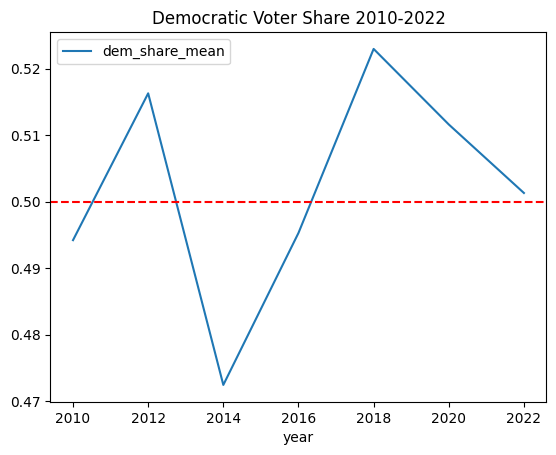

In [27]:
yearly_demShare_avg = house[house['uncontested'] == False].groupby('year').agg(dem_share_mean = ('dem_share', 'mean'))
yearly_demShare_avg.plot(y='dem_share_mean', kind='line')
plt.axhline(0.5, color='red', linestyle='--')
plt.title('Democratic Voter Share 2010-2022')
plt.show()

In [28]:
contested= house[(house['uncontested'] == False) & (house['dem_share'].notna())]
contested['winner'] = np.where(contested['dem_share'] > 0.5, 'D', 'R')
contested['winner'].value_counts()
uncontested= house[(house['uncontested'] == True)].copy()
uncontested['winner'] = np.where(uncontested['dem_votes'] > 1, 'D', 'R')


/var/folders/9x/sklrh8m161l783pbftltsvgc0000gn/T/ipykernel_95767/1849591223.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  contested['winner'] = np.where(contested['dem_share'] > 0.5, 'D', 'R')


In [29]:
house_with_winner = pd.concat([contested, uncontested])
seat_counts = house_with_winner.groupby(['year', 'winner']).size().unstack()
print(seat_counts)

winner    D    R
year            
2010    193  242
2012    200  235
2014    187  248
2016    193  242
2018    231  204
2020    223  213
2022    212  223


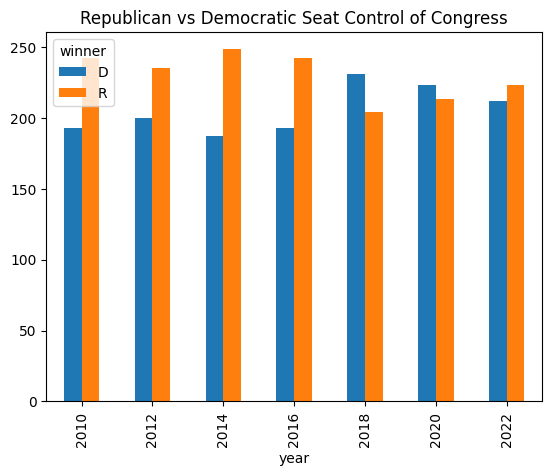

In [30]:
house_with_winner[house_with_winner['year'] == 2018]['winner'].value_counts()
uncontested[uncontested['year'] == 2018]['winner'].value_counts()
seat_counts.plot(kind='bar')
plt.title('Republican vs Democratic Seat Control of Congress') 
plt.show()


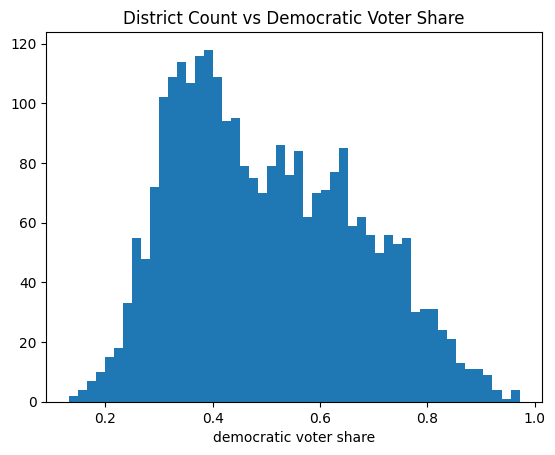

In [31]:
plt.hist(contested['dem_share'], bins=50)
plt.title('District Count vs Democratic Voter Share')
plt.xlabel('democratic voter share')
plt.show()

In [32]:
print(house.head())


   year state_po  district  dem_votes  other_votes  rep_votes  dem_share  \
0  2010       AK         0      77606            0     175384   0.306755   
1  2010       AL         1          0        26357     129063        NaN   
2  2010       AL         2     106865            0     111645   0.489062   
3  2010       AL         3      80204            0     117736   0.405193   
4  2010       AL         4          0            0     167714        NaN   

   uncontested  partisan_lean  gdp_growth_q2  unemp_oct  log_gdp_growth  \
0        False         -15.21            3.9        9.4        1.589235   
1         True         -28.61            3.9        9.4        1.589235   
2        False         -30.97            3.9        9.4        1.589235   
3        False         -31.37            3.9        9.4        1.589235   
4         True         -59.81            3.9        9.4        1.589235   

   midterm_year  redistricted  
0             1             0  
1             1             

In [33]:
house = house.sort_values(['state_po', 'district', 'year'])
house['dem_share_prev'] = house.groupby(['state_po', 'district'])['dem_share'].shift(1)
house['incumbent_party'] = np.where(
    house['dem_share_prev'] > 0.5, 1,
    np.where(house['dem_share_prev'].isna(), 0, -1)
)
house.head()

,year,state_po,district,dem_votes,other_votes,rep_votes,dem_share,uncontested,partisan_lean,gdp_growth_q2,unemp_oct,log_gdp_growth,midterm_year,redistricted,dem_share_prev,incumbent_party
0,2010,AK,0,77606,0,175384,0.306755,False,-15.21,3.9,9.4,1.589235,1,0,NaN,0
435,2012,AK,0,82927,20617,185296,0.309172,False,-15.21,1.8,7.8,1.029619,0,0,0.306755,-1
870,2014,AK,0,114602,21290,142572,0.445620,False,-15.21,5.3,5.7,1.840550,1,0,0.309172,-1
1305,2016,AK,0,111019,40863,155088,0.417197,False,-15.21,1.3,4.9,0.832909,0,0,0.445620,-1
1740,2018,AK,0,131199,0,149779,0.466937,False,-15.21,2.1,3.8,1.131402,1,0,0.417197,-1


In [34]:
with open(houseweek1_merged, "w") as file: 
    file.write(house.to_csv(index=False))
